In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

C:\Users\bosjgj\AppData\Local\Temp\ipykernel_20356\3939813039.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(scenario_data.values(), labels=scenario_data.keys(), patch_artist=True)


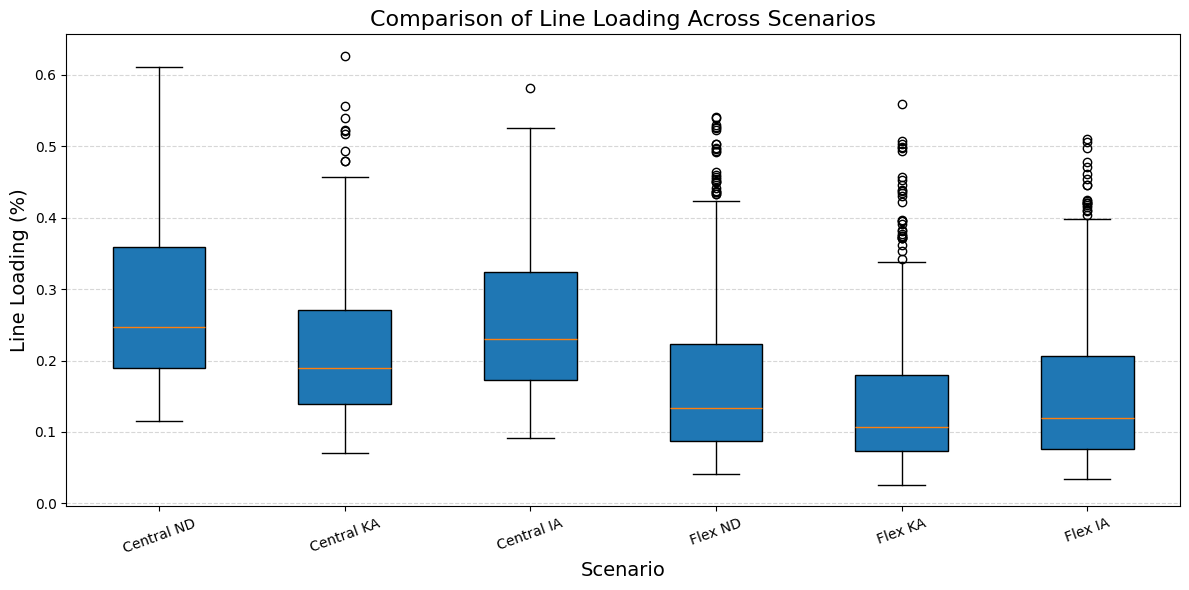

In [2]:
scenarios = {
    "Central ND": "line_loading_1_central_nd.csv",
    "Central KA": "line_loading_1_central_ka.csv",
    "Central IA": "line_loading_1_central_ia.csv",
    "Flex ND": "line_loading_1_flex_nd.csv",
    "Flex KA": "line_loading_1_flex_ka.csv",
    "Flex IA": "line_loading_1_flex_ia.csv"
}

# Load data for each scenario
scenario_data = {}
for scenario, file in scenarios.items():
    df = pd.read_csv(file)
    
    # Assuming the line loading column is named "line_loading"
    scenario_data[scenario] = df["line_loading"]

# Create a boxplot
plt.figure(figsize=(12, 6))
plt.boxplot(scenario_data.values(), labels=scenario_data.keys(), patch_artist=True)

# Formatting
plt.ylabel("Line Loading (%)", fontsize=14)
plt.xlabel("Scenario", fontsize=14)
plt.title("Comparison of Line Loading Across Scenarios", fontsize=16)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Show the plot
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("line_loading_boxplot.pdf", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\bosjgj\AppData\Local\Temp\ipykernel_20356\2955540023.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f"{int(y * 100)}%" for y in yticks if y >= 0])


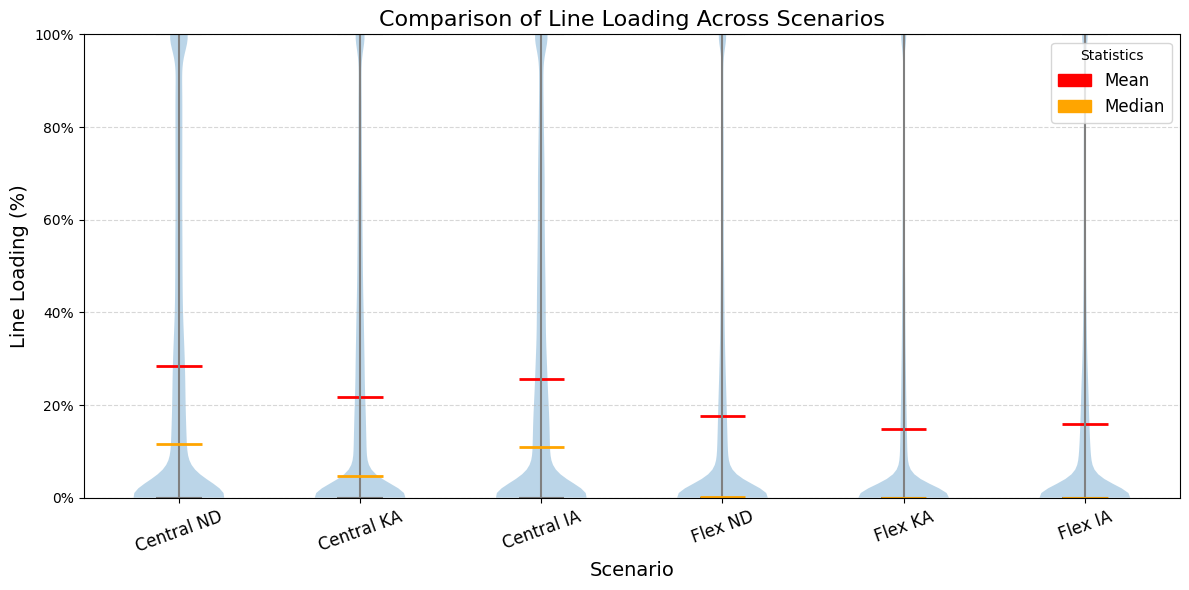

In [3]:
scenarios = {
    "Central ND": "line_loading_all_central_nd.csv",
    "Central KA": "line_loading_all_ka_central.csv",
    "Central IA": "line_loading_all_central_ia.csv",
    "Flex ND": "line_loading_all_flex_nd.csv",
    "Flex KA": "line_loading_all_flex_ka.csv",
    "Flex IA": "line_loading_all_flex_ia.csv"
}
# Load data for each scenario
scenario_data = []
scenario_labels = []

for scenario, file in scenarios.items():
    df = pd.read_csv(file)
    
    # Ensure "line_loading" column exists
    if "line_loading" in df.columns:
        scenario_data.append(df["line_loading"])
        scenario_labels.append(scenario)

# Create the violin plot
plt.figure(figsize=(12, 6))
violin_parts = plt.violinplot(scenario_data, showmeans=True, showmedians=True)

# Customize min/max bars
for partname in ['cbars', 'cmins', 'cmaxes']:
    violin_parts[partname].set_edgecolor("grey")  # Grey min/max bars for better contrast

# Change mean line to red and median to orange
violin_parts['cmeans'].set_color('red')
violin_parts['cmeans'].set_linewidth(2)

violin_parts['cmedians'].set_color('orange')
violin_parts['cmedians'].set_linewidth(2)

# Formatting
plt.xticks(range(1, len(scenario_labels) + 1), scenario_labels, rotation=20, fontsize=12)
plt.ylabel("Line Loading (%)", fontsize=14)
plt.xlabel("Scenario", fontsize=14)
plt.title("Comparison of Line Loading Across Scenarios", fontsize=16)

# ✅ **Fix: Adaptive Y-Axis Scaling**
max_line_loading = max(max(data) for data in scenario_data)  # Find highest loading
plt.ylim(0, min(1, max_line_loading + 0.05))  # Start at 0, add 5% buffer, max 100%

# Convert y-axis to percentage format
yticks = plt.gca().get_yticks()
plt.gca().set_yticklabels([f"{int(y * 100)}%" for y in yticks if y >= 0])

# Add grid for better readability
plt.grid(axis="y", linestyle="--", alpha=0.5)

# **Create legend for mean & median**
legend_patches = [
    mpatches.Patch(color="red", label="Mean"),
    mpatches.Patch(color="orange", label="Median"),
]
plt.legend(handles=legend_patches, loc="upper right", fontsize=12, title="Statistics", frameon=True)

# Show the plot
plt.tight_layout()
plt.savefig("line_loading_violin_ll.pdf", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\bosjgj\AppData\Local\Temp\ipykernel_20356\755558938.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f"{int(y * 100)}%" for y in yticks if y >= 0])


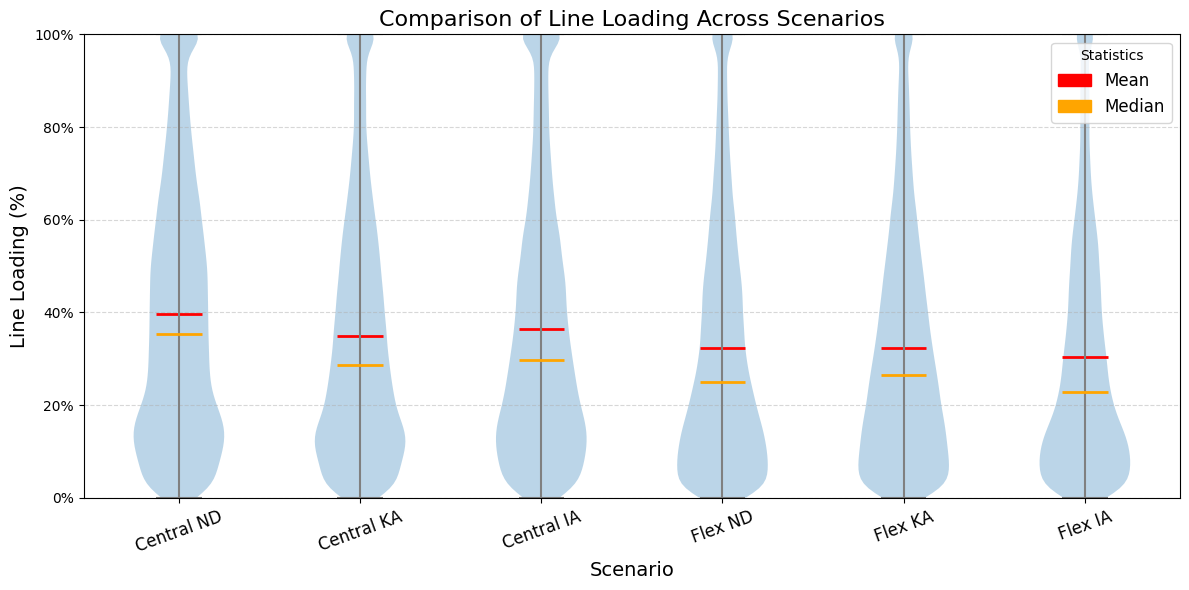

In [4]:
scenarios = {
    "Central ND": "line_loading_all_central_nd_base.csv",
    "Central KA": "line_loading_all_central_ka_base.csv",
    "Central IA": "line_loading_all_central_ia_base.csv",
    "Flex ND": "line_loading_all_flex_nd_base.csv",
    "Flex KA": "line_loading_all_flex_ka_base.csv",
    "Flex IA": "line_loading_all_flex_ia_base.csv"
}
# Load data for each scenario
scenario_data = []
scenario_labels = []

for scenario, file in scenarios.items():
    df = pd.read_csv(file)
    
    # Ensure "line_loading" column exists
    if "line_loading" in df.columns:
        scenario_data.append(df["line_loading"])
        scenario_labels.append(scenario)

# Create the violin plot
plt.figure(figsize=(12, 6))
violin_parts = plt.violinplot(scenario_data, showmeans=True, showmedians=True)

# Customize min/max bars
for partname in ['cbars', 'cmins', 'cmaxes']:
    violin_parts[partname].set_edgecolor("grey")  # Grey min/max bars for better contrast

# Change mean line to red and median to orange
violin_parts['cmeans'].set_color('red')
violin_parts['cmeans'].set_linewidth(2)

violin_parts['cmedians'].set_color('orange')
violin_parts['cmedians'].set_linewidth(2)

# Formatting
plt.xticks(range(1, len(scenario_labels) + 1), scenario_labels, rotation=20, fontsize=12)
plt.ylabel("Line Loading (%)", fontsize=14)
plt.xlabel("Scenario", fontsize=14)
plt.title("Comparison of Line Loading Across Scenarios", fontsize=16)

# ✅ **Fix: Adaptive Y-Axis Scaling**
max_line_loading = max(max(data) for data in scenario_data)  # Find highest loading
plt.ylim(0, min(1, max_line_loading + 0.05))  # Start at 0, add 5% buffer, max 100%

# Convert y-axis to percentage format
yticks = plt.gca().get_yticks()
plt.gca().set_yticklabels([f"{int(y * 100)}%" for y in yticks if y >= 0])

# Add grid for better readability
plt.grid(axis="y", linestyle="--", alpha=0.5)

# **Create legend for mean & median**
legend_patches = [
    mpatches.Patch(color="red", label="Mean"),
    mpatches.Patch(color="orange", label="Median"),
]
plt.legend(handles=legend_patches, loc="upper right", fontsize=12, title="Statistics", frameon=True)

# Show the plot
plt.tight_layout()
plt.savefig("line_loading_violin_cost_opt.pdf", dpi=300, bbox_inches="tight")
plt.show()

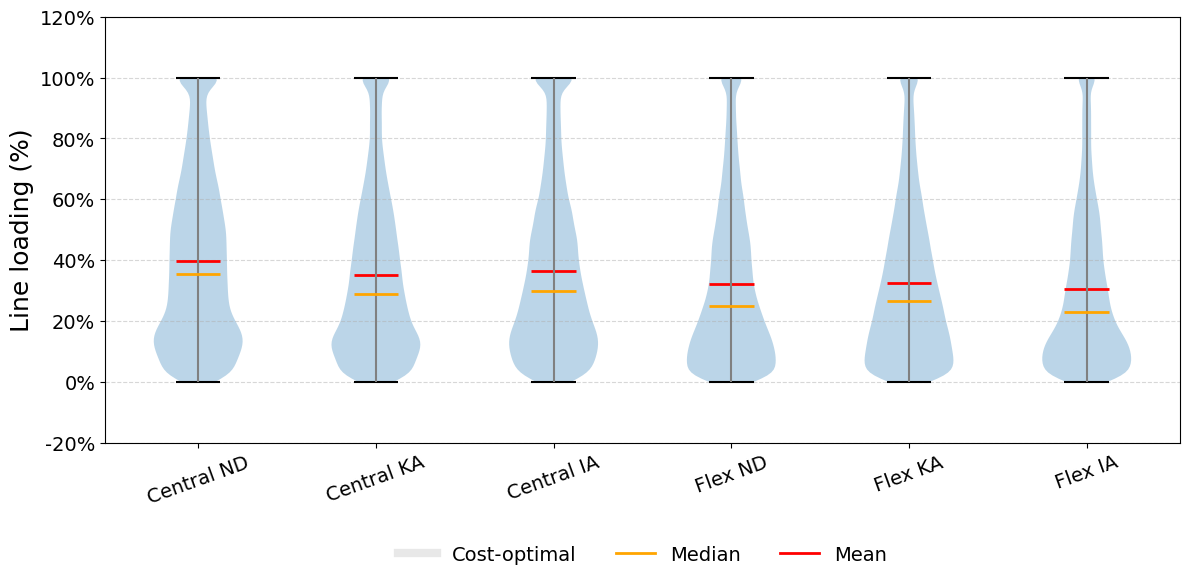

In [22]:
# Define the scenario file mappings for cost-optimal cases only
cost_opt_scenarios = {
    "Central ND": "line_loading_all_central_nd_base.csv",
    "Central KA": "line_loading_all_central_ka_base.csv",
    "Central IA": "line_loading_all_central_ia_base.csv",
    "Flex ND": "line_loading_all_flex_nd_base.csv",
    "Flex KA": "line_loading_all_flex_ka_base.csv",
    "Flex IA": "line_loading_all_flex_ia_base.csv"
}

# Load data for each scenario
cost_opt_data = []
scenario_labels = []

for scenario, file in cost_opt_scenarios.items():
    df_cost = pd.read_csv(file)
    if "line_loading" in df_cost.columns:
        cost_opt_data.append(df_cost["line_loading"])
        scenario_labels.append(scenario)

# Customize appearance
plt.figure(figsize=(12, 6))
violin_parts = plt.violinplot(scenario_data, showmeans=True, showmedians=True)

# Customize min/max bars
for partname in ['cbars', 'cmins', 'cmaxes']:
    violin_parts[partname].set_edgecolor("grey")  # Grey min/max bars for better contrast

# Change mean line to red and median to orange
violin_parts['cmeans'].set_color('red')
violin_parts['cmeans'].set_linewidth(2)

violin_parts['cmedians'].set_color('orange')
violin_parts['cmedians'].set_linewidth(2)

# Set whiskers (min/max bars) to black
for partname in ["cmins", "cmaxes"]:
    violin_parts[partname].set_color("black")

# Formatting
plt.xticks(range(1, len(scenario_labels) + 1), scenario_labels, rotation=20, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Line loading (%)", fontsize=18)
# plt.title("Cost-Optimal Line Loading Across Scenarios", fontsize=16)

# Convert y-axis to percentage format
plt.gca().set_yticks(plt.gca().get_yticks())
plt.gca().set_yticklabels([f"{int(y * 100)}%" for y in plt.gca().get_yticks()])

# Add grid for readability
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add legend manually
legend_handles = [
    plt.Line2D([0], [0], color="lightgray", lw=6, alpha=0.5, label="Cost-optimal"),
    plt.Line2D([0], [0], color="orange", lw=2, label="Median"),
    plt.Line2D([0], [0], color="red", lw=2, label="Mean")
]
plt.legend(handles=legend_handles, loc="upper center", fontsize=14, 
           bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)

# Show and save the plot
plt.tight_layout()
plt.savefig("line_loading_cost_opt_violinplot.pdf", dpi=300, bbox_inches="tight")
plt.show()

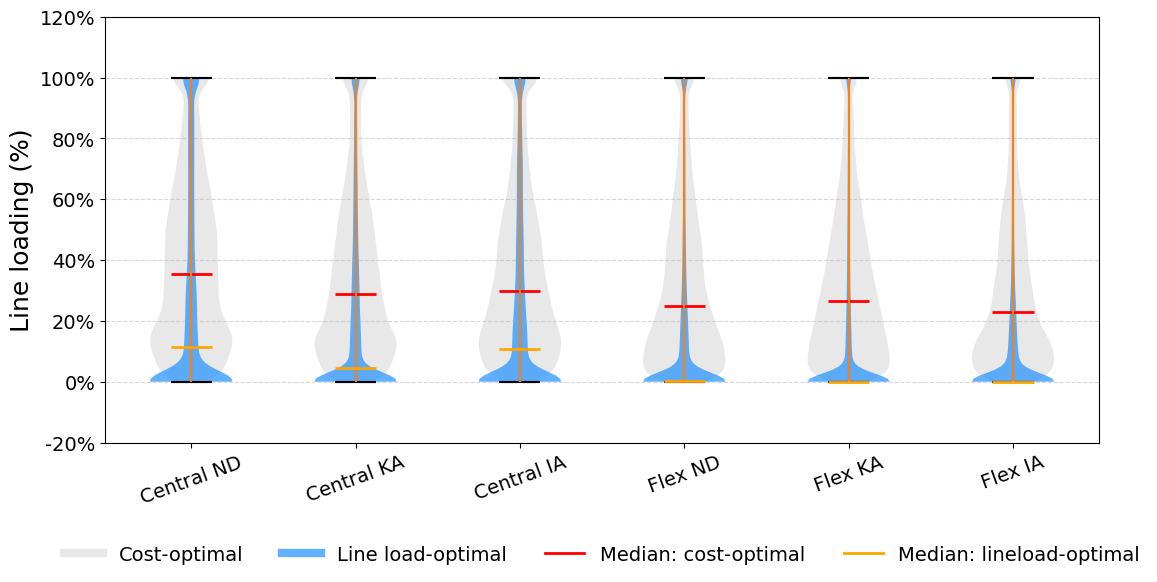

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the scenario file mappings for cost-optimal and line load-optimal
cost_opt_scenarios = {
    "Central ND": "line_loading_all_central_nd_base.csv",
    "Central KA": "line_loading_all_central_ka_base.csv",
    "Central IA": "line_loading_all_central_ia_base.csv",
    "Flex ND": "line_loading_all_flex_nd_base.csv",
    "Flex KA": "line_loading_all_flex_ka_base.csv",
    "Flex IA": "line_loading_all_flex_ia_base.csv"
}

line_load_opt_scenarios = {
    "Central ND": "line_loading_all_central_nd.csv",
    "Central KA": "line_loading_all_ka_central.csv",
    "Central IA": "line_loading_all_central_ia.csv",
    "Flex ND": "line_loading_all_flex_nd.csv",
    "Flex KA": "line_loading_all_flex_ka.csv",
    "Flex IA": "line_loading_all_flex_ia.csv"
}

# Load data for each scenario
cost_opt_data = []
line_load_opt_data = []
scenario_labels = []

for scenario in cost_opt_scenarios.keys():
    # Load cost-optimal data
    df_cost = pd.read_csv(cost_opt_scenarios[scenario])
    if "line_loading" in df_cost.columns:
        cost_opt_data.append(df_cost["line_loading"])
    
    # Load line load-optimal data
    df_line_load = pd.read_csv(line_load_opt_scenarios[scenario])
    if "line_loading" in df_line_load.columns:
        line_load_opt_data.append(df_line_load["line_loading"])
    
    scenario_labels.append(scenario)

# Create the figure
plt.figure(figsize=(12, 6))

# Plot the cost-optimal violin plot in the BACK (more transparent)
violin_parts_cost = plt.violinplot(cost_opt_data, showmedians=True)
for part in violin_parts_cost["bodies"]:
    part.set_facecolor("lightgray")  # Light gray background
    part.set_alpha(0.5)  # More transparent

# Plot the line load-optimal violin plot in the FRONT (more visible)
violin_parts_line = plt.violinplot(line_load_opt_data, showmedians=True)
for part in violin_parts_line["bodies"]:
    part.set_facecolor("dodgerblue")  # Blue for line loading version
    part.set_alpha(0.7)  # Less transparent

# Customize mean and median lines
for violin_parts in [violin_parts_cost]:
    violin_parts["cmedians"].set_color("red")  # Median in orange
    violin_parts["cmedians"].set_linewidth(2)

# Customize mean and median lines
for violin_parts in [violin_parts_line]:
    violin_parts["cmedians"].set_color("orange")  # Median in orange
    violin_parts["cmedians"].set_linewidth(2)

for partname in ["cmins", "cmaxes"]:
    violin_parts[partname].set_color("black")

# Formatting
plt.xticks(range(1, len(scenario_labels) + 1), scenario_labels, rotation=20, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Line loading (%)", fontsize=18)
# plt.title("Comparison of line loading across scenarios", fontsize=16)

# Convert y-axis to percentage format
plt.gca().set_yticks(plt.gca().get_yticks())
plt.gca().set_yticklabels([f"{int(y * 100)}%" for y in plt.gca().get_yticks()])

# Add grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add a legend manually
legend_handles = [
    plt.Line2D([0], [0], color="lightgray", lw=6, alpha=0.5, label="Cost-optimal"),
    plt.Line2D([0], [0], color="dodgerblue", lw=6, alpha=0.7, label="Line load-optimal"),
    plt.Line2D([0], [0], color="red", lw=2, label="Median: cost-optimal"),
    plt.Line2D([0], [0], color="orange", lw=2, label="Median: lineload-optimal"),
]
plt.legend(handles=legend_handles, loc="upper center", fontsize=14, 
           bbox_to_anchor=(0.5, -0.2), ncol=4, frameon=False) 

# Show and save the plot
plt.tight_layout()
plt.savefig("line_loading_violin_lineload.pdf", dpi=300, bbox_inches="tight")
plt.show()
